# Notebook 02 — Conjugate Unknown Observation Variance

**Reference:** W&H: Basic Analysis: A Trend/Seasonal DLM (scalar p=1 case)

**New engine function:** `kalman_filter_conjugate(spec, y, n0, d0)`

## 1. Motivation

In notebooks so far, $V$ (observation noise variance) was treated as *known*. In practice it is estimated from data — either by MLE, or, properly, as a Bayesian unknown.

The **conjugate prior** for the variance of a normal likelihood is the **Inverse-Gamma**:

$$
V \sim \text{IG}(n_0/2,\; d_0/2)
$$

with mean $d_0 / (n_0 - 2)$ for $n_0 > 2$. This prior is conjugate to the normal likelihood, meaning the posterior is also inverse-gamma, and can be updated analytically at each time step.

The result is that the **predictive distribution for $y_t$** is a **Student-t**, not a Gaussian — wider tails because $V$ is uncertain.

## 2. The conjugate update (scalar $p = 1$)

At time $t-1$, the joint posterior is:

$$
(\theta_t, V) \mid y_{1:t-1} \sim \text{NIG}(m_{t-1}, C_{t-1} V, n_{t-1}/2, d_{t-1}/2)
$$

After observing $y_t$, the update is (W&H: Basic Analysis: A Trend/Seasonal DLM):

$$
\begin{aligned}
n_t &= n_{t-1} + 1 \\
q_t^* &= F R_t F' + 1 \quad \text{(predictive scale factor, without V)} \\
e_t &= y_t - F a_t \\
d_t &= d_{t-1} + \frac{e_t^2}{q_t^*} \\
\hat{V}_t &= d_t / n_t \quad \text{(running posterior mean of V)}
\end{aligned}
$$

The state is updated using the Kalman gain computed with the **prior** estimate $\hat{V}_{t-1} = d_{t-1}/n_{t-1}$:

$$
A_t = \frac{R_t F'}{q_t^*}, \quad m_t = a_t + A_t e_t, \quad C_t = \frac{d_t}{n_t} \left(R_t - A_t q_t^* A_t'\right)
$$

The **predictive density** is Student-t with $n_{t-1}$ degrees of freedom:

$$
y_t \mid y_{1:t-1} \sim t_{n_{t-1}}\!\left(F a_t,\; \hat{V}_{t-1} q_t^*\right)
$$

In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parents[1]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import matplotlib.pyplot as plt

from engine.conjugate import kalman_filter_conjugate
from engine.filter import kalman_filter
from engine.models import make_local_level
from engine.simulate import simulate

## 3. Implementation: running V estimate

In [2]:
# Simulate a local-level series
V_true = 2.0
W_true = 0.05
spec = make_local_level(V=V_true, W_level=W_true)
sim = simulate(spec, n=300, seed=11)
y = sim.y

# Vague IG prior: n0=2, d0 chosen so d0/(n0-2) is technically undefined (vague)
# Use n0=4, d0=4*1.0 as a weakly informative prior centred on V=1
cr = kalman_filter_conjugate(spec, y, n0=4.0, d0=4.0 * 1.0)

# Also run the fixed-V filter for comparison
fr = kalman_filter(spec, y)

print(f"Final V estimate: {cr.v_hat[-1]:.3f}  (true V = {V_true})")
print(f"Conjugate log-lik: {cr.loglik:.2f}   Fixed-V log-lik: {fr.loglik:.2f}")

Final V estimate: 1.714  (true V = 2.0)
Conjugate log-lik: -547.09   Fixed-V log-lik: -542.46


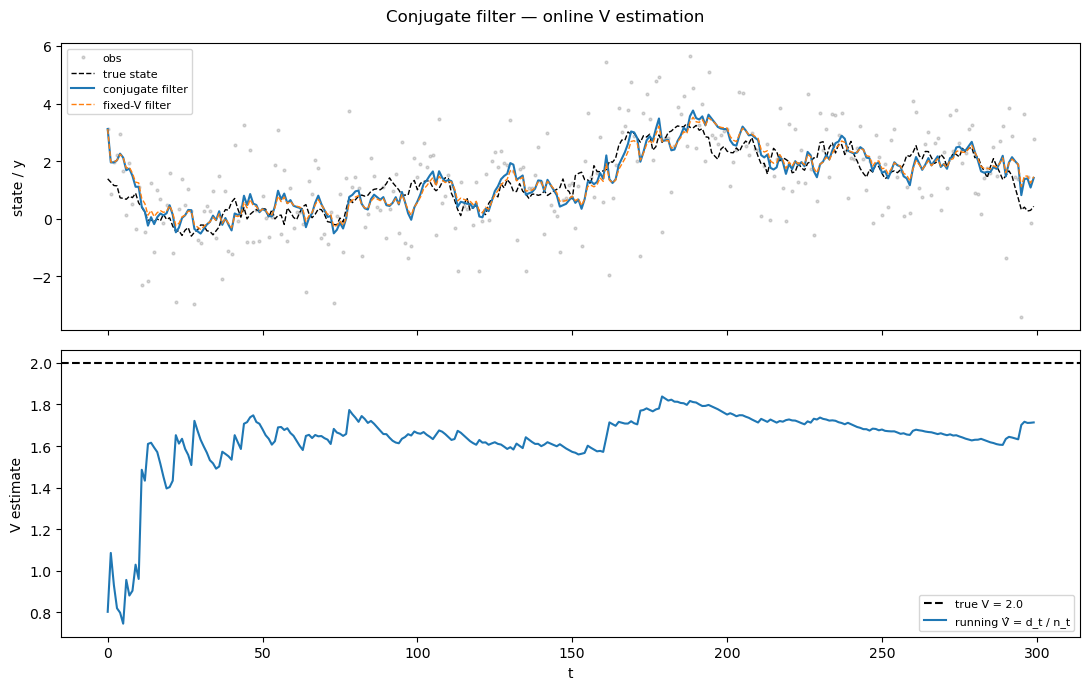

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
t = np.arange(len(y))

# Panel 1: state estimates
ax1.plot(t, y[:, 0], 'o', ms=2, alpha=0.3, color='grey', label='obs')
ax1.plot(t, sim.theta_true[:, 0], 'k--', lw=1, label='true state')
ax1.plot(t, cr.m[:, 0], 'C0', lw=1.5, label='conjugate filter')
ax1.plot(t, fr.m[:, 0], 'C1', lw=1, ls='--', label='fixed-V filter')
ax1.set_ylabel('state / y')
ax1.legend(fontsize=8)

# Panel 2: running V estimate
ax2.axhline(V_true, color='k', ls='--', label=f'true V = {V_true}')
ax2.plot(t, cr.v_hat, 'C0', label='running V̂ = d_t / n_t')
ax2.set(xlabel='t', ylabel='V estimate')
ax2.legend(fontsize=8)

plt.suptitle('Conjugate filter — online V estimation')
plt.tight_layout()
plt.show()

## 4. Effect of the prior

The rate at which $\hat{V}_t$ converges to $V_{\text{true}}$ depends on how informative the prior is ($n_0$ controls this — larger $n_0$ means a tighter prior).

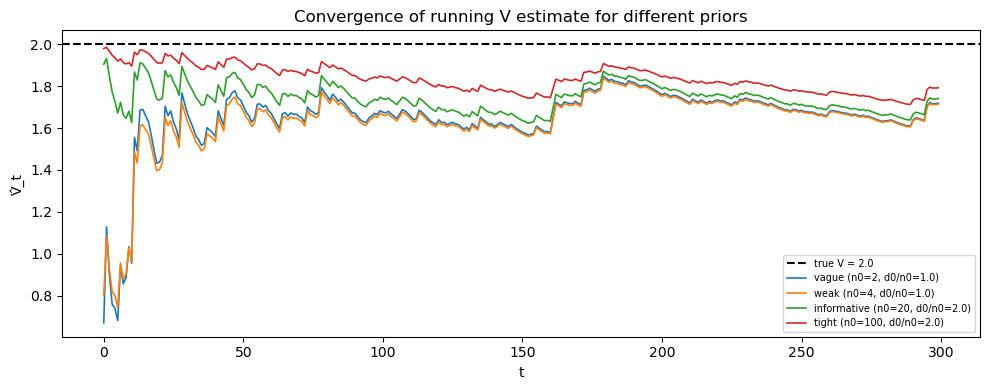

In [4]:
priors = [
    (2.0, 2.0 * 1.0, 'vague (n0=2, d0/n0=1.0)'),
    (4.0, 4.0 * 1.0, 'weak (n0=4, d0/n0=1.0)'),
    (20.0, 20.0 * V_true, f'informative (n0=20, d0/n0={V_true})'),
    (100.0, 100.0 * V_true, f'tight (n0=100, d0/n0={V_true})'),
]

plt.figure(figsize=(10, 4))
t = np.arange(len(y))
plt.axhline(V_true, color='k', ls='--', label=f'true V = {V_true}')
for n0, d0, label in priors:
    cr_p = kalman_filter_conjugate(spec, y, n0=n0, d0=d0)
    plt.plot(t, cr_p.v_hat, lw=1.2, label=label)
plt.xlabel('t'); plt.ylabel('V̂_t')
plt.title('Convergence of running V estimate for different priors')
plt.legend(fontsize=7)
plt.tight_layout()
plt.show()

## 5. Exercises

**Exercise 1.** The conjugate filter's log-likelihood is the sum of Student-t log densities, not Gaussian. For a large informative prior on $V$ (e.g. `n0=1000, d0=1000*V_true`), verify that `cr.loglik` converges to `fr.loglik` (the fixed-V Gaussian log-lik). Why should this be true?

In [5]:
# YOUR CODE HERE


**Exercise 2.** With a vague prior (`n0=2, d0=2`), run the conjugate filter on a series where the true $V$ changes abruptly at $t=150$ (e.g. $V=1$ for $t<150$, $V=4$ for $t \ge 150$). Simulate this as two concatenated segments. Does the running estimate $\hat{V}_t$ adapt to the change? Why or why not?

In [6]:
# YOUR CODE HERE
# Hint: simulate two segments and concatenate their .y arrays


**Exercise 3.** Check that the degrees of freedom array `cr.n` is exactly `[n0+1, n0+2, ..., n0+T]`. Explain why $n_t$ increases by exactly 1 per observation.

In [7]:
# YOUR CODE HERE
cr_check = kalman_filter_conjugate(spec, y, n0=4.0, d0=4.0)
T = len(y)
expected_n = np.arange(5.0, 5.0 + T)
# assert np.allclose(cr_check.n, expected_n)
